# Load USGS variometer station locations on a map

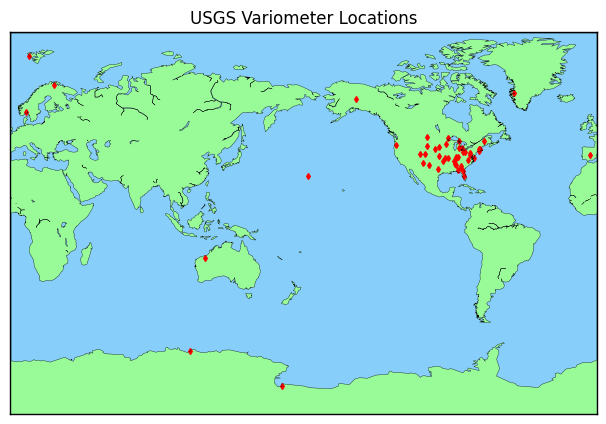

In [2]:
from pyspedas.tplot_tools.MPLPlotter.tplot_map import tplot_map, tplot_trace_tvars_to_tmap, add_markers, add_station_fovs
from pyspedas.projects.themis import state
from pyspedas.projects.themis.ground import gmag
import datetime as dt
import numpy as np
import matplotlib.pyplot as plt

fig=plt.figure(figsize=(8,4.5))
ax = fig.add_axes([0.05,0.05,0.9,0.85])

# mercator/2D map 
tmap = tplot_map(llcrnrlon=0,llcrnrlat=-85,urcrnrlon=360,urcrnrlat=85,projection='mill')
tmap._params.drawmapboundary = {"fill_color":"lightskyblue"}
tmap._params.fillcontinents = {"color":"palegreen","lake_color":"lightskyblue"}

# Add ground station markers
themis_gmag_dict = gmag.Themis_gmag()
for station_dict in themis_gmag_dict.get_gmag_list():
    if station_dict['variom'] == 'Y':
        tmap = add_markers(coords=np.array([0,float(station_dict['lat']),float(station_dict['lng'])]),tmap=tmap,label=station_dict['ccode'],ms=3)

tmap.add_map_boundary()
tmap.add_fillcontinents()
tmap.add_coastlines(linewidth=0.25)
#date_str = '2026-02-03'
#tmap.add_nightshade(date=dt.datetime.strptime(date_str+" 15:00:00",'%Y-%m-%d %H:%M:%S'))
plt.title("USGS Variometer Locations")
#ax.legend()
plt.show()

# Plot trace footpaths alongside variometer station markers 

Import packages:

In [4]:
from pyspedas.tplot_tools.MPLPlotter.tplot_map import tplot_map, tplot_trace_tvars_to_tmap, add_markers, add_station_fovs, tvar_to_foottracks, add_tracks
from pyspedas.projects.themis import state
from pyspedas.projects.themis.ground import gmag
import datetime as dt
import numpy as np
import matplotlib.pyplot as plt

Create tplot variables THEMIS A and THEMIS D positional data:

In [5]:
date_str = '2026-01-20'
time_range = [date_str,date_str]
state(trange=time_range, probe='a')
state(trange=time_range, probe='d')

25-Jun-26 18:33:35: File is current: themis_data/tha/l1/state/2026/tha_l1_state_20260120.cdf
25-Jun-26 18:33:36: File is current: themis_data/thd/l1/state/2026/thd_l1_state_20260120.cdf


['thd_pos',
 'thd_vel',
 'thd_spin_initial_delta_phi',
 'thd_spin_idpu_spinper',
 'thd_spin_segflags',
 'thd_spin_ecl_initial_delta_phi',
 'thd_spin_ecl_idpu_spinper',
 'thd_spin_ecl_segflags',
 'thd_pos_gse',
 'thd_pos_gsm',
 'thd_vel_gse',
 'thd_vel_gsm',
 'thd_pos_sel',
 'thd_pos_sse',
 'thd_vel_sel',
 'thd_vel_sse']

Compute traces:

In [6]:
trace_a = tvar_to_foottracks(tvar_to_trace = 'tha_pos_gsm', model_str = "t89", endpoint = "ionosphere-north")
trace_d = tvar_to_foottracks(tvar_to_trace = 'thd_pos_gsm', model_str = "t89", endpoint = "ionosphere-north")

25-Jun-26 18:33:41: The km parameter is deprecated. Please use units_in, foot_out_units, and trace_out_units instead.
25-Jun-26 18:33:41: Setting units_in, foot_out_units, and trace_out_units to 'km'.
25-Jun-26 18:33:41: Setting units for input_var_re
25-Jun-26 18:33:41: get_t89_parameters: No kp, iopt, or parmod data provided, defaulting to iopt=3


Load IGRF coefficients ...


25-Jun-26 18:33:45: Computed 100/1440 traces so far, current trace time 2026-01-20 01:40:00.000000
25-Jun-26 18:33:49: Computed 200/1440 traces so far, current trace time 2026-01-20 03:20:00.000000
25-Jun-26 18:33:52: Computed 300/1440 traces so far, current trace time 2026-01-20 05:00:00.000000
25-Jun-26 18:33:53: Computed 400/1440 traces so far, current trace time 2026-01-20 06:40:00.000000
25-Jun-26 18:33:57: Computed 500/1440 traces so far, current trace time 2026-01-20 08:20:00.000000
25-Jun-26 18:34:01: Computed 600/1440 traces so far, current trace time 2026-01-20 10:00:00.000000
25-Jun-26 18:34:06: Computed 700/1440 traces so far, current trace time 2026-01-20 11:40:00.000000
25-Jun-26 18:34:14: Computed 800/1440 traces so far, current trace time 2026-01-20 13:20:00.000000
25-Jun-26 18:34:23: Computed 900/1440 traces so far, current trace time 2026-01-20 15:00:00.000000
25-Jun-26 18:34:33: Computed 1000/1440 traces so far, current trace time 2026-01-20 16:40:00.000000
25-Jun-26

Initialize THEMIS GMAG dictionary:

In [7]:
themis_gmag_dict = gmag.Themis_gmag()

Determine which variometer stations are closest to the THEMIS A,D footpaths:

In [8]:
def vpolar_to_vcartesian(theta,phi):
    return (np.sin(theta)*np.cos(phi), np.sin(theta)*np.sin(phi), np.cos(theta))

variom_dist_list = []
for station_dict in themis_gmag_dict.get_gmag_list():
    if station_dict['variom'] == 'Y':
        # Determine angular separation; assume sphere
        # station:
        s_theta = np.deg2rad(90.0-float(station_dict['lat']))
        s_phi = np.deg2rad(float(station_dict['lng']))
        s_x, s_y, s_z = vpolar_to_vcartesian(s_theta,s_phi)
        
        t_a_theta = np.deg2rad(90.0 - (trace_a[0])[:,1])
        t_a_phi = np.deg2rad((trace_a[0])[:,2])
        t_a_x, t_a_y, t_a_z = vpolar_to_vcartesian(t_a_theta,t_a_phi)

        t_d_theta = np.deg2rad(90.0 - (trace_d[0])[:,1])
        t_d_phi = np.deg2rad((trace_d[0])[:,2])
        t_d_x, t_d_y, t_d_z = vpolar_to_vcartesian(t_d_theta,t_d_phi)
        
        ang_sep_a = np.rad2deg( np.arccos( (s_x*t_a_x)+(s_y*t_a_y)+(s_z*t_a_z) ) )
        ang_sep_d = np.rad2deg( np.arccos( (s_x*t_d_x)+(s_y*t_d_y)+(s_z*t_d_z) ) )

        #lat_sep_a = float(station_dict['lat'])-(trace_a[0])[:,1]
        #lon_sep_a = float(station_dict['lng'])-(trace_a[0])[:,2]
        #ang_sep_a = np.sqrt(lat_sep_a**2 + lon_sep_a**2)

        #lat_sep_d = float(station_dict['lat'])-(trace_d[0])[:,1]
        #lon_sep_d = float(station_dict['lng'])-(trace_d[0])[:,2]
        #ang_sep_d = np.sqrt(lat_sep_d**2 + lon_sep_d**2)

        dist_tuple = (station_dict['ccode'],np.min(ang_sep_a),np.min(ang_sep_d))
        variom_dist_list.append(dist_tuple)

num_listed = 5

print("Top " + str(num_listed) + " closest stations to THEMIS A:")
variom_dist_list.sort(key=lambda distance: distance[1])
for entry in variom_dist_list[0:num_listed]:
    print("Station: " + entry[0] + "; angular separation: %.2f degrees" % entry[1]) 
#print(variom_dist_list)

print("Top " + str(num_listed) + " closest stations to THEMIS D:")
variom_dist_list.sort(key=lambda distance: distance[2])
for entry in variom_dist_list[0:num_listed]:
    print("Station: " + entry[0] + "; angular separation: %.2f degrees" % entry[2])

Top 5 closest stations to THEMIS A:
Station: KEVO; angular separation: 0.83 degrees
Station: COLA; angular separation: 1.82 degrees
Station: KONO; angular separation: 8.85 degrees
Station: KBS; angular separation: 9.00 degrees
Station: SFJD; angular separation: 9.13 degrees
Top 5 closest stations to THEMIS D:
Station: KEVO; angular separation: 0.05 degrees
Station: SFJD; angular separation: 6.76 degrees
Station: COLA; angular separation: 6.83 degrees
Station: PAB; angular separation: 7.66 degrees
Station: KONO; angular separation: 8.75 degrees


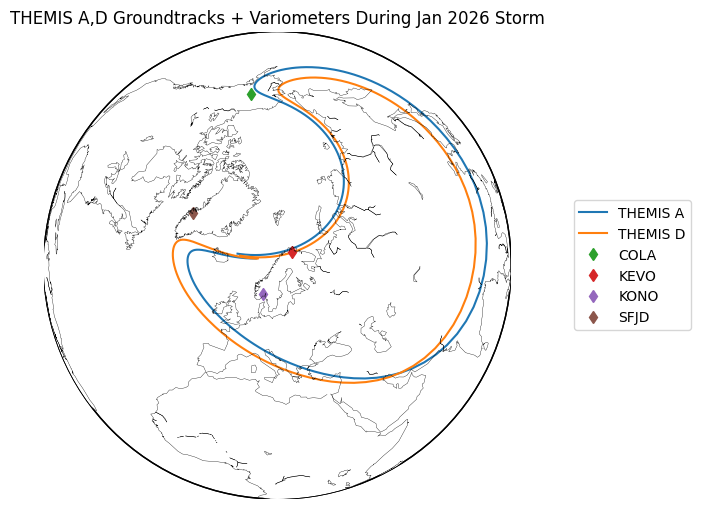

In [9]:
fig=plt.figure(figsize=(8,5.5))
ax = fig.add_axes([0.05,0.05,0.9,0.85])

mean_lat_a = np.mean((trace_a[0])[:,1])
mean_lon_a = np.mean((trace_a[0])[:,2])
mean_lat_d = np.mean((trace_d[0])[:,1])
mean_lon_d = np.mean((trace_d[0])[:,2])

mean_lat = np.mean([mean_lat_a,mean_lat_d])
mean_lon = np.mean([mean_lon_a,mean_lon_d])

# Initialize map:
#tmap = tplot_map(lat_0=50,lon_0=80)
tmap = tplot_map(lat_0=mean_lat,lon_0=mean_lon)

tmap._params.add_marker = {"linestyle":"","marker":"d"}

# Add ground tracks:
tmap = add_tracks(tmap=tmap, coords=trace_a[0], label = 'THEMIS A')
tmap = add_tracks(tmap=tmap, coords=trace_d[0], label = 'THEMIS D')

# Add ground station markers
for station_dict in themis_gmag_dict.get_gmag_list():
    if station_dict['variom'] == 'Y':
        if station_dict['ccode'] in ["KEVO","COLA","KONO","SFJD"]:
            tmap = add_markers(coords=np.array([0,float(station_dict['lat']),float(station_dict['lng'])]),tmap=tmap,label=station_dict['ccode'],ms=6)
        
tmap.add_map_boundary()
tmap.add_fillcontinents()
tmap.add_coastlines(linewidth=0.25)
#tmap.add_nightshade(date=dt.datetime.strptime(date_str+" 12:00:00",'%Y-%m-%d %H:%M:%S'))

plt.title("THEMIS A,D Groundtracks + Variometers During Jan 2026 Storm")
ax.legend(loc="center right",bbox_to_anchor=(1, 0, 0.4, 1))
plt.show()

Download THEMIS A,D FGM data and KEVO, COLA magnetic field data for the date of the geomagnetic storm:

In [ ]:
from pyspedas.projects.themis.spacecraft.fields.fit import fit
from pyspedas.tplot_tools.tplot_names import tplot_names
fit(trange=time_range,probe='a',get_support_data=True)
fit(trange=time_range,probe='d',get_support_data=True)
gmag.gmag(trange=time_range,sites=["kevo","cola"])
tplot_names()

25-Jun-26 18:38:24: Downloading remote index: https://themis.ssl.berkeley.edu/data/themis/tha/l2/fit/2026/
25-Jun-26 18:38:25: File is current: themis_data/tha/l2/fit/2026/tha_l2_fit_20260120_v01.cdf
25-Jun-26 18:38:25: Unable to get ydata for variable tha_fgs_sigma
25-Jun-26 18:38:25: Downloading remote index: https://themis.ssl.berkeley.edu/data/themis/thd/l2/fit/2026/
25-Jun-26 18:38:27: File is current: themis_data/thd/l2/fit/2026/thd_l2_fit_20260120_v01.cdf
25-Jun-26 18:38:28: Downloading remote index: https://themis.ssl.berkeley.edu/data/themis/thg/l2/variometers/kevo/2026/
25-Jun-26 18:38:29: File is current: themis_data/thg/l2/variometers/kevo/2026/thg_l2_mag_kevo_20260120_v01.cdf
25-Jun-26 18:38:29: Downloading remote index: https://themis.ssl.berkeley.edu/data/themis/thg/l2/variometers/cola/2026/
25-Jun-26 18:38:31: File is current: themis_data/thg/l2/variometers/cola/2026/thg_l2_mag_cola_20260120_v01.cdf


0 : tha_pos
1 : tha_vel
2 : tha_spin_initial_delta_phi
3 : tha_spin_idpu_spinper
4 : tha_spin_segflags
5 : tha_spin_ecl_initial_delta_phi
6 : tha_spin_ecl_idpu_spinper
7 : tha_spin_ecl_segflags
8 : tha_pos_gse
9 : tha_pos_gsm
10 : tha_vel_gse
11 : tha_vel_gsm
12 : tha_pos_sel
13 : tha_pos_sse
14 : tha_vel_sel
15 : tha_vel_sse
16 : thd_pos
17 : thd_vel
18 : thd_spin_initial_delta_phi
19 : thd_spin_idpu_spinper
20 : thd_spin_segflags
21 : thd_spin_ecl_initial_delta_phi
22 : thd_spin_ecl_idpu_spinper
23 : thd_spin_ecl_segflags
24 : thd_pos_gse
25 : thd_pos_gsm
26 : thd_vel_gse
27 : thd_vel_gsm
28 : thd_pos_sel
29 : thd_pos_sse
30 : thd_vel_sel
31 : thd_vel_sse
32 : input_var_re
33 : tha_pos_gsm_trace_iono_n_t89
34 : tha_pos_gsmt89ifoot_n
35 : thd_pos_gsm_trace_iono_n_t89
36 : thd_pos_gsmt89ifoot_n
37 : tha_fgs_dsl
38 : tha_fgs_gse
39 : tha_fgs_gsm
40 : thd_fgs_sigma
41 : thd_fgs_dsl
42 : thd_fgs_gse
43 : thd_fgs_gsm
44 : thd_efs_sigma
45 : thd_efs_dsl
46 : thd_efs_0_dsl
47 : thd_efs_dot0_

['tha_pos',
 'tha_vel',
 'tha_spin_initial_delta_phi',
 'tha_spin_idpu_spinper',
 'tha_spin_segflags',
 'tha_spin_ecl_initial_delta_phi',
 'tha_spin_ecl_idpu_spinper',
 'tha_spin_ecl_segflags',
 'tha_pos_gse',
 'tha_pos_gsm',
 'tha_vel_gse',
 'tha_vel_gsm',
 'tha_pos_sel',
 'tha_pos_sse',
 'tha_vel_sel',
 'tha_vel_sse',
 'thd_pos',
 'thd_vel',
 'thd_spin_initial_delta_phi',
 'thd_spin_idpu_spinper',
 'thd_spin_segflags',
 'thd_spin_ecl_initial_delta_phi',
 'thd_spin_ecl_idpu_spinper',
 'thd_spin_ecl_segflags',
 'thd_pos_gse',
 'thd_pos_gsm',
 'thd_vel_gse',
 'thd_vel_gsm',
 'thd_pos_sel',
 'thd_pos_sse',
 'thd_vel_sel',
 'thd_vel_sse',
 'input_var_re',
 'tha_pos_gsm_trace_iono_n_t89',
 'tha_pos_gsmt89ifoot_n',
 'thd_pos_gsm_trace_iono_n_t89',
 'thd_pos_gsmt89ifoot_n',
 'tha_fgs_dsl',
 'tha_fgs_gse',
 'tha_fgs_gsm',
 'thd_fgs_sigma',
 'thd_fgs_dsl',
 'thd_fgs_gse',
 'thd_fgs_gsm',
 'thd_efs_sigma',
 'thd_efs_dsl',
 'thd_efs_0_dsl',
 'thd_efs_dot0_dsl',
 'thd_efs_gse',
 'thd_efs_0_gse',


Perform median subtraction:

Plot magnetic field measurements for THEMIS A, D, COLA, and KEVO in the same time period:

25-Jun-26 18:38:44: wildcard_expand: No match found for tha_fit_bfit


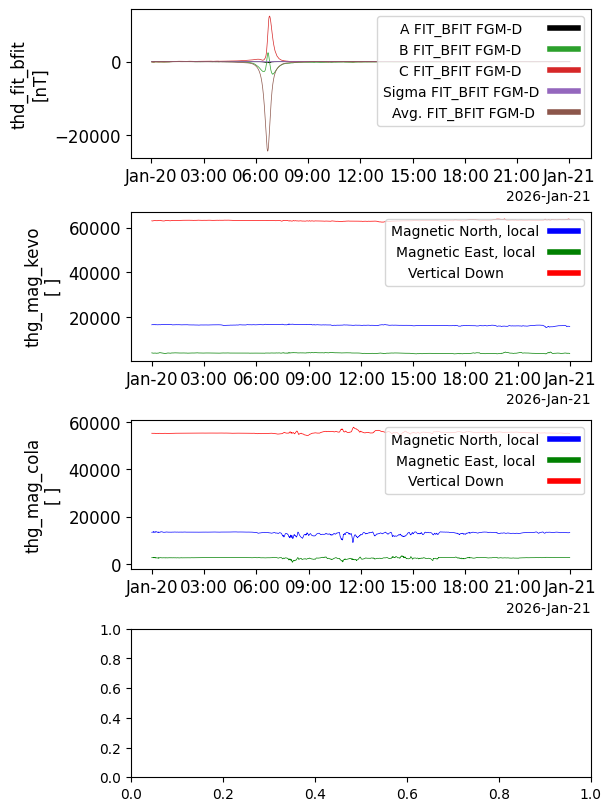

25-Jun-26 18:38:45: C:\Users\DC\AppData\Local\Temp\ipykernel_27144\2945385478.py:5: UserWarning: The figure layout has changed to tight
  fig.tight_layout()



In [ ]:
from pyspedas.tplot_tools.MPLPlotter.tplot import tplot
fig, axs = plt.subplots(4,layout="constrained",figsize=(6,8))
# 'tha_fgs_btotal', 
tplot(['tha_fgs_gse','thd_fgs_gse','thg_mag_kevo','thg_mag_cola'],fig=fig,axis=axs)
fig.tight_layout()